In [3]:
import os
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
for split in sorted(os.listdir(DATASET_PATH)):
    split_path = os.path.join(DATASET_PATH, split)
    if os.path.isdir(split_path):
        for cls in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                print(f"  {split}/{cls}: {len(os.listdir(cls_path))} images")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  Testing/glioma: 400 images
  Testing/meningioma: 400 images
  Testing/notumor: 400 images
  Testing/pituitary: 400 images
  Training/glioma: 1400 images
  Training/meningioma: 1400 images
  Training/notumor: 1400 images
  Training/pituitary: 1400 images


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

In [5]:
TRAIN_PATH  = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
TEST_PATH   = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS_1    = 10
EPOCHS_2    = 8
NUM_CLASSES = 4

CLASS_NAMES = sorted(os.listdir(TRAIN_PATH))
print("Classes:", CLASS_NAMES)
print("Train:", os.listdir(TRAIN_PATH))
print("Test:", os.listdir(TEST_PATH))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: ['pituitary', 'notumor', 'meningioma', 'glioma']
Test: ['pituitary', 'notumor', 'meningioma', 'glioma']


In [6]:
# NO rescaling — EfficientNetB0 handles normalization internally
train_datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Class indices:", train_generator.class_indices)
print(f"Train: {train_generator.samples} | Test: {test_generator.samples}")

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Train: 5600 | Test: 1600


In [7]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1781973649.182711      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,416,039 (16.85 MB)

 Trainable params: 363,908 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [8]:
callbacks_1 = [
    EarlyStopping(monitor="val_accuracy", patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                      patience=2, verbose=1),
    # weights-only format — version-independent, no deserialization issues
    ModelCheckpoint("best_phase1.weights.h5", monitor="val_accuracy",
                    save_best_only=True, save_weights_only=True, verbose=1)
]

print("Phase 1: Frozen base training...")
history_1 = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS_1,
    callbacks=callbacks_1
)

# Load best phase 1 weights back into model
model.load_weights("best_phase1.weights.h5")

# Save full model immediately as H5 — don't wait till end
model.save("brain_tumor_phase1.h5")
print("[SAVED] brain_tumor_phase1.h5")

Phase 1: Frozen base training...
Epoch 1/10


I0000 00:00:1781973681.272616     148 service.cc:152] XLA service 0x7c6e9c0016d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781973681.272680     148 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781973683.607522     148 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781973695.172035     148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.6860 - loss: 0.9035
Epoch 1: val_accuracy improved from None to 0.76437, saving model to best_phase1.weights.h5

Epoch 1: finished saving model to best_phase1.weights.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 132s 617ms/step - accuracy: 0.7557 - loss: 0.6776 - val_accuracy: 0.7644 - val_loss: 0.6189 - learning_rate: 0.0010
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.8181 - loss: 0.4519
Epoch 2: val_accuracy improved from 0.76437 to 0.83500, saving model to best_phase1.weights.h5

Epoch 2: finished saving model to best_phase1.weights.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 68s 387ms/step - accuracy: 0.8386 - loss: 0.4255 - val_accuracy: 0.8350 - val_loss: 0.5151 - learning_rate: 0.0010
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.8712 - loss: 0.3545
Epoch 3: val_accuracy did not improve from 0.83500
175/175 ━━━━━━━━━━━━━━━━━━━━ 66s 379ms/step - accuracy: 0.8720 - loss: 0.3534 - val_accuracy: 0.8325 - v

[SAVED] brain_tumor_phase1.h5


In [9]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_2 = [
    EarlyStopping(monitor="val_accuracy", patience=4,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                      patience=2, verbose=1),
    ModelCheckpoint("best_phase2.weights.h5", monitor="val_accuracy",
                    save_best_only=True, save_weights_only=True, verbose=1)
]

print("Phase 2: Fine-tuning...")
history_2 = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS_2,
    callbacks=callbacks_2
)

# Load best phase 2 weights
model.load_weights("best_phase2.weights.h5")

# Save final model as H5 immediately
model.save("brain_tumor_classifier.h5")
print("[SAVED] brain_tumor_classifier.h5")

Phase 2: Fine-tuning...
Epoch 1/8


2026-06-20 16:59:23.086261: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 16:59:23.292378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 16:59:23.715414: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-20 16:59:23.921529: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.8208 - loss: 0.4893
Epoch 1: val_accuracy improved from None to 0.87000, saving model to best_phase2.weights.h5

Epoch 1: finished saving model to best_phase2.weights.h5
175/175 ━━━━━━━━━━━━━━━━━━━━ 100s 414ms/step - accuracy: 0.8348 - loss: 0.4572 - val_accuracy: 0.8700 - val_loss: 0.4693 - learning_rate: 1.0000e-05
Epoch 2/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.8608 - loss: 0.3546
Epoch 2: val_accuracy did not improve from 0.87000
175/175 ━━━━━━━━━━━━━━━━━━━━ 66s 377ms/step - accuracy: 0.8675 - loss: 0.3473 - val_accuracy: 0.8619 - val_loss: 0.4917 - learning_rate: 1.0000e-05
Epoch 3/8
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8839 - loss: 0.3116
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 3: val_accuracy did not improve from 0.87000
175/175 ━━━━━━━━━━━━━━━━━━━━ 67s 382ms/step - accuracy: 0.8832 - loss: 0.3200 - val_accuracy: 0.8656 - val_loss: 0.4816 - 

[SAVED] brain_tumor_classifier.h5


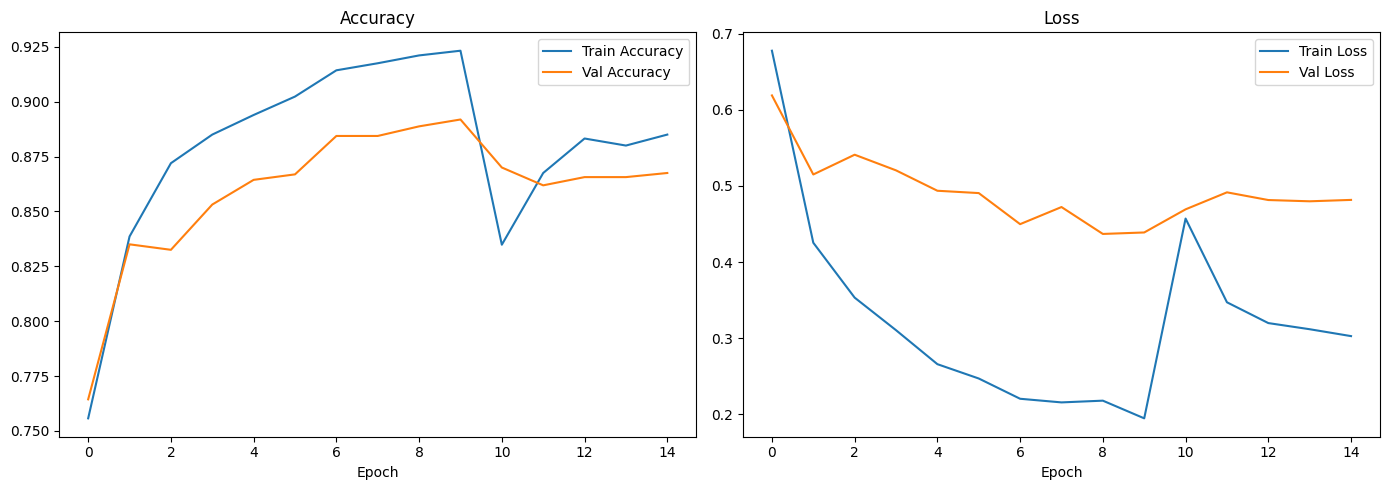

[SAVED] training_curves.png


In [10]:
acc      = history_1.history["accuracy"]     + history_2.history["accuracy"]
val_acc  = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]
loss     = history_1.history["loss"]         + history_2.history["loss"]
val_loss = history_1.history["val_loss"]     + history_2.history["val_loss"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(acc, label="Train Accuracy")
ax1.plot(val_acc, label="Val Accuracy")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(loss, label="Train Loss")
ax2.plot(val_loss, label="Val Loss")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("[SAVED] training_curves.png")

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

test_generator.reset()
raw_preds = model.predict(test_generator, verbose=1)
y_pred    = np.argmax(raw_preds, axis=1)
y_true    = test_generator.classes
labels    = list(test_generator.class_indices.keys())

precision = precision_score(y_true, y_pred, average="weighted")
recall    = recall_score(y_true, y_pred, average="weighted")
f1        = f1_score(y_true, y_pred, average="weighted")
_, test_acc = model.evaluate(test_generator, verbose=0)

print("=" * 50)
print("      EVALUATION METRICS (Test Set)")
print("=" * 50)
print(f"  Test Accuracy : {test_acc * 100:.2f}%")
print(f"  Precision     : {precision * 100:.2f}%")
print(f"  Recall        : {recall * 100:.2f}%")
print(f"  F1 Score      : {f1 * 100:.2f}%")
print("=" * 50)
print(classification_report(y_true, y_pred, target_names=labels))

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step
      EVALUATION METRICS (Test Set)
  Test Accuracy : 87.00%
  Precision     : 87.30%
  Recall        : 87.00%
  F1 Score      : 86.60%
              precision    recall  f1-score   support

      glioma       0.93      0.72      0.81       400
  meningioma       0.82      0.78      0.80       400
     notumor       0.86      0.99      0.92       400
   pituitary       0.87      0.99      0.93       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600



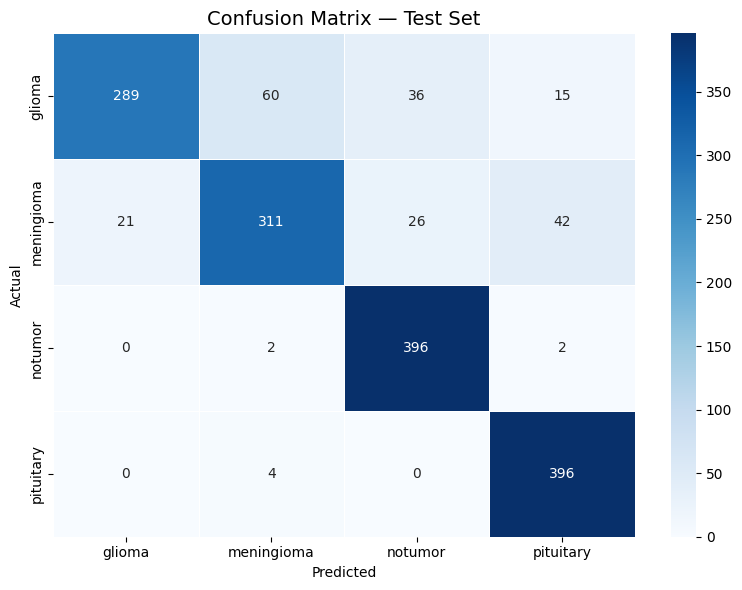

[SAVED] confusion_matrix.png


In [12]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, linewidths=0.5)
plt.title("Confusion Matrix — Test Set", fontsize=14)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("[SAVED] confusion_matrix.png")

In [13]:
import os

files = os.listdir("/kaggle/working")
print("Files in /kaggle/working:")
for f in sorted(files):
    size = os.path.getsize(f"/kaggle/working/{f}") / (1024*1024)
    print(f"  {f}: {size:.1f} MB")

print("\n--- Copy into MODEL_METRICS in app.py ---")
print(f'    "test_accuracy":  {round(test_acc * 100, 2)},')
print(f'    "precision":      {round(precision * 100, 2)},')
print(f'    "recall":         {round(recall * 100, 2)},')
print(f'    "f1_score":       {round(f1 * 100, 2)},')

Files in /kaggle/working:
  .virtual_documents: 0.0 MB
  best_phase1.weights.h5: 20.2 MB
  best_phase2.weights.h5: 31.7 MB
  brain_tumor_classifier.h5: 31.8 MB
  brain_tumor_phase1.h5: 20.3 MB
  confusion_matrix.png: 0.1 MB
  training_curves.png: 0.1 MB

--- Copy into MODEL_METRICS in app.py ---
    "test_accuracy":  87.0,
    "precision":      87.3,
    "recall":         87.0,
    "f1_score":       86.6,
